# HarvestGuard ML — v2

Runs locally against `Banana D1.csv` in this folder. No Colab paths, no `/content`.

From the repository root:

```bash
.venv/bin/pip install -r requirements-train.txt
.venv/bin/python -m jupyter lab model_train/HarvestGuard_ML_v1.ipynb
```

All data-building logic lives in `harvestguard_data.py` and the fitting logic in
`train.py`. This notebook imports both so it cannot drift from the artifacts the
API actually serves — run `python model_train/train.py` to regenerate those.

### What changed from v1, and why

| v1 | Problem | v2 |
|---|---|---|
| Class trends invented as absolute rates | All three classes sat within ±1.25σ of the sensor's own noise floor | Bands defined in units of the **measured** noise floor |
| Ranges overlapped on `[0.03, 0.05]` and `[0.12, 0.18]` | Genuinely ambiguous labels | Contiguous, non-overlapping bands |
| Temp/humidity trends keyed to the label | Model solved the task from two fully-synthetic channels and **ignored gas entirely** | Environmental drift sampled independently of the label |
| `(last - first) / n` over 30 samples | Used 2 of 30 samples; swamped by noise | Least-squares slope over 60 samples |
| `np.clip()` to the observed range | Flattened the very trend being learned | Removed |
| Warm-up transient left in | First ~15 s is heater stabilisation, inflating the noise floor 47% | Detected and trimmed |
| Random train/test split | 60-wide windows over 241 samples ⇒ near-duplicates on both sides | Split by disjoint window position |
| Accuracy 0.9717 | Measured how well a net inverts a linear generator | 0.7610, against a **0.7789 ceiling** |

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))

import harvestguard_data as hg
import train as hg_train

print("window size :", hg.WINDOW_SIZE, "s at 1 Hz")
print("features    :", hg.FEATURE_NAMES)

window size : 60 s at 1 Hz
features    : ['temperature', 'humidity', 'gas_raw', 'temperature_rate', 'humidity_rate', 'gas_rate']


## 2. The real recording

`Banana D1.csv` logs 10 MQ gas channels for 4 minutes. Only MQ3 (alcohol) is used
here — note that MQ135 and MQ4 track ammonia and ethylene, which are more directly
relevant to fruit ripening and are worth revisiting.

In [2]:
raw = pd.read_csv(hg.CSV_PATH)
print(raw.shape)
raw.head()

(27707, 10)


,Ticks,MQ2,MQ3,MQ4,MQ5,MQ6,MQ7,MQ8,MQ9,MQ135
0,1648640854091,54,82,79,19,70,36,63,61,493
1,1648640854104,61,80,80,20,65,33,64,60,501
2,1648640854112,55,82,75,16,67,35,65,61,496
3,1648640854120,58,81,76,16,67,32,60,58,498
4,1648640854128,56,79,77,19,65,34,63,63,496


In [3]:
signal = hg.load_real_gas()
print(signal.summary())

Banana D1: 27707 raw rows over 240.5 s
  dropped 15 s of sensor warm-up -> 226 usable samples at 1 Hz
  MQ3 mean=103.17 sd=2.72 range=[94, 112]
  noise floor at W=60s: sigma_null=0.0682 units/s


### 2a. The warm-up transient

MQ-series sensors need their heater to stabilise. The opening seconds ramp at up to
**+1.10 units/s** — an order of magnitude faster than anything the fruit does. v1
sampled training windows across this region, which inflated the measured noise floor
by 47% and injected a spurious upward drift into every window drawn from it.

detected warm-up end: 15 s


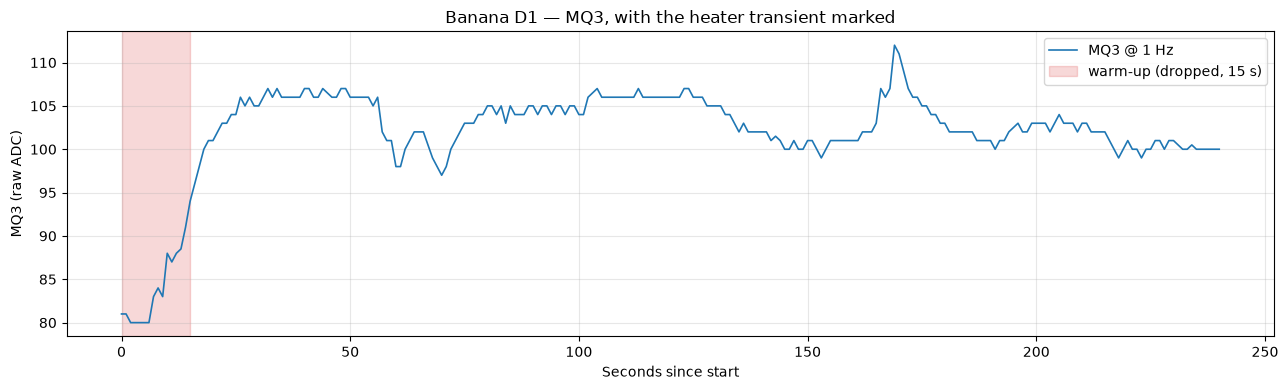

In [4]:
full = pd.read_csv(hg.CSV_PATH)[["Ticks", "MQ3"]].copy()
full["datetime"] = pd.to_datetime(full["Ticks"], unit="ms")
full_1s = full.set_index("datetime")["MQ3"].resample("1s").median().dropna()

warmup = hg.detect_warmup_end(full_1s.to_numpy(dtype=float))
print(f"detected warm-up end: {warmup} s")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.arange(len(full_1s)), full_1s.to_numpy(), lw=1.2, label="MQ3 @ 1 Hz")
ax.axvspan(0, warmup, alpha=0.18, color="tab:red", label=f"warm-up (dropped, {warmup} s)")
ax.set_xlabel("Seconds since start")
ax.set_ylabel("MQ3 (raw ADC)")
ax.set_title("Banana D1 — MQ3, with the heater transient marked")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The noise floor — the number v1 never measured

The banana does not spoil in four minutes, so every window slope in this recording is
**noise**. Its spread, `sigma_null`, is the smallest trend the sensor can resolve.
Any class boundary below it is undetectable by construction.

In [5]:
values = signal.values
rows = []
for W in [15, 30, 60, 90]:
    if len(values) <= W:
        continue
    slopes = np.array([hg.ols_slope(values[i:i + W]) for i in range(len(values) - W)])
    rows.append({"window_s": W, "n_windows": len(slopes),
                 "sigma_null": slopes.std(ddof=1)})

noise = pd.DataFrame(rows)
noise["1_sigma_rise_over_window"] = noise.sigma_null * noise.window_s
display(noise.round(4))

print(f"\nChosen window: {hg.WINDOW_SIZE} s  ->  sigma_null = {signal.sigma_null:.4f} units/s")

,window_s,n_windows,sigma_null,1_sigma_rise_over_window
0,15,211,0.2702,4.0533
1,30,196,0.1668,5.0048
2,60,166,0.0682,4.0940
3,90,136,0.0253,2.2798



Chosen window: 60 s  ->  sigma_null = 0.0682 units/s


### 3a. Why the v1 class ranges could not work

In [6]:
V1_RANGES = {"Safe": (-0.03, 0.05), "Act Soon": (0.03, 0.18), "Critical": (0.12, 0.35)}
V1_WINDOW = 30

# v1 did not trim warm-up and used a 30 s window, so this is the noise floor it
# was actually operating against -- the fair basis for judging its class bands.
full_values = full_1s.to_numpy(dtype=float)
v1_slopes = np.array([
    (full_values[i + V1_WINDOW - 1] - full_values[i]) / V1_WINDOW
    for i in range(len(full_values) - V1_WINDOW)
])
v1_sigma = v1_slopes.std(ddof=1)

print(f"v1 noise floor (30 s window, warm-up left in): sigma_null = {v1_sigma:.4f} units/s")
print(f"v2 noise floor (60 s window, warm-up trimmed): sigma_null = {signal.sigma_null:.4f} units/s\n")

print("v1 bands against v1's own noise floor:\n")
for name, (lo, hi) in V1_RANGES.items():
    print(f"  {name:9} [{lo:6.2f}, {hi:5.2f}] units/s "
          f"= [{lo / v1_sigma:6.2f}, {hi / v1_sigma:5.2f}] sigma_null")

print("\n  Every band lies inside +/-1.3 sigma of the sensor doing nothing, so no")
print("  boundary was resolvable. Safe/Act Soon also overlap on [0.03, 0.05] and")
print("  Act Soon/Critical on [0.12, 0.18], making those labels genuinely ambiguous.\n")

print("v2 bands (contiguous, non-overlapping, defined in sigma_null):\n")
for label, (lo, hi) in hg.GAS_BANDS_SIGMA.items():
    print(f"  {hg.LABEL_NAMES[label]:9} [{lo:5.1f}, {hi:5.1f}] sigma_null "
          f"= [{lo * signal.sigma_null:6.3f}, {hi * signal.sigma_null:6.3f}] units/s")

v1 noise floor (30 s window, warm-up left in): sigma_null = 0.2412 units/s
v2 noise floor (60 s window, warm-up trimmed): sigma_null = 0.0682 units/s

v1 bands against v1's own noise floor:

  Safe      [ -0.03,  0.05] units/s = [ -0.12,  0.21] sigma_null
  Act Soon  [  0.03,  0.18] units/s = [  0.12,  0.75] sigma_null
  Critical  [  0.12,  0.35] units/s = [  0.50,  1.45] sigma_null

  Every band lies inside +/-1.3 sigma of the sensor doing nothing, so no
  boundary was resolvable. Safe/Act Soon also overlap on [0.03, 0.05] and
  Act Soon/Critical on [0.12, 0.18], making those labels genuinely ambiguous.

v2 bands (contiguous, non-overlapping, defined in sigma_null):

  Safe      [ -1.0,   1.5] sigma_null = [-0.068,  0.102] units/s
  Act Soon  [  1.5,   3.5] sigma_null = [ 0.102,  0.239] units/s
  Critical  [  3.5,   7.0] sigma_null = [ 0.239,  0.478] units/s


## 4. Building the dataset

Gas windows are real segments (mean-centred, so only genuine sensor texture survives)
with a class-dependent trend added. Temperature and humidity remain fully synthetic —
**there is still no real environmental recording** — but their drift is now drawn
*independently of the label*, so the network cannot use them as a shortcut.

The split is by window **position**: windows are 60 samples wide over 226, so
neighbouring start positions produce near-duplicate segments and a random split would
place near-copies on both sides.

In [7]:
train_starts, test_starts = hg.split_start_indices(signal)
print(f"train starts {train_starts.min():3d}..{train_starts.max():3d}  (n={len(train_starts)})")
print(f"test  starts {test_starts.min():3d}..{test_starts.max():3d}  (n={len(test_starts)})")
print(f"guard band of {hg.WINDOW_SIZE} samples between them — no window spans both")

train_df = hg.build_dataset(signal, hg_train.SAMPLES_PER_CLASS_TRAIN, train_starts, seed=hg_train.SEED)
test_df = hg.build_dataset(signal, hg_train.SAMPLES_PER_CLASS_TEST, test_starts, seed=hg_train.SEED + 1)

print(f"\ntrain {train_df.shape}   test {test_df.shape}")
train_df.head()

train starts   0.. 63  (n=64)
test  starts 124..165  (n=42)
guard band of 60 samples between them — no window spans both



train (12000, 7)   test (3000, 7)


,temperature,humidity,gas_raw,temperature_rate,humidity_rate,gas_rate,label
0,29.562980,65.974204,105.823280,-0.002644,-0.001844,-0.007794,0
1,31.989651,62.510535,106.804457,0.005964,-0.006136,0.068980,0
2,25.183948,75.667908,95.880792,0.001130,0.001151,0.038383,0
3,30.875295,63.819469,87.397690,0.000976,-0.018365,-0.047083,0
4,29.558361,54.213093,112.357763,0.004308,0.006807,-0.097072,0


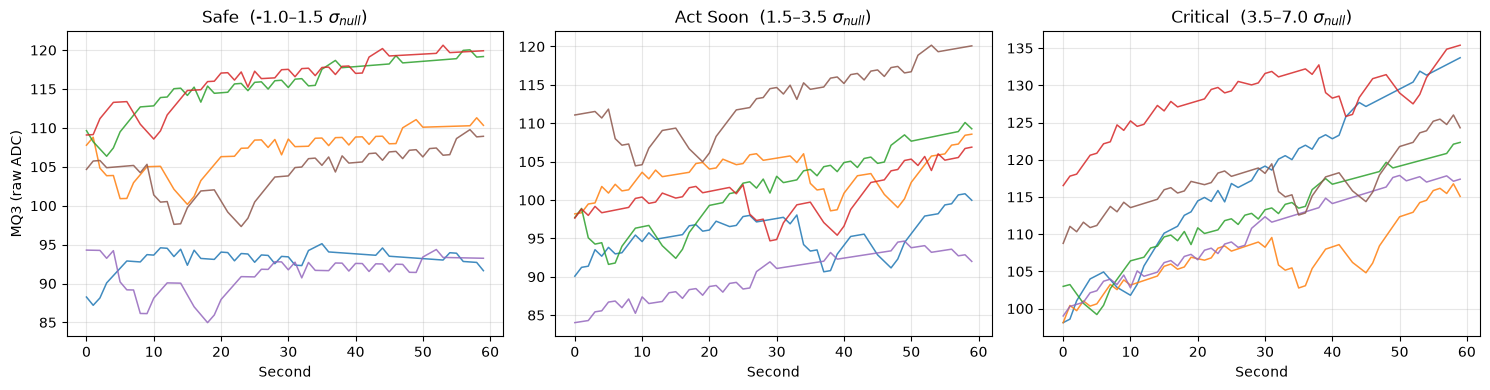

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rng = np.random.default_rng(0)

for ax, (label, name) in zip(axes, hg.LABEL_NAMES.items()):
    for _ in range(6):
        start = int(rng.choice(train_starts))
        _, _, gas = hg.generate_window(label, signal, rng, start)
        ax.plot(gas, lw=1.1, alpha=0.85)
    ax.set_title(f"{name}  ({hg.GAS_BANDS_SIGMA[label][0]:.1f}–"
                 f"{hg.GAS_BANDS_SIGMA[label][1]:.1f} $\\sigma_{{null}}$)")
    ax.set_xlabel("Second")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("MQ3 (raw ADC)")
plt.tight_layout()
plt.show()

### 4a. Which features actually carry the label

F-ratio = between-class spread ÷ within-class spread. In v1 this was 1.92 for
`humidity_rate` and 0.36 for `gas_rate` — the gas channel was the *least* useful
feature in a gas-sensing project.

In [9]:
X = train_df[hg.FEATURE_NAMES].to_numpy()
y = train_df["label"].to_numpy()

rows = []
for j, name in enumerate(hg.FEATURE_NAMES):
    means = np.array([X[y == k, j].mean() for k in sorted(hg.LABEL_NAMES)])
    within = np.sqrt(np.mean([X[y == k, j].var() for k in sorted(hg.LABEL_NAMES)]))
    rows.append({"feature": name, "F_ratio": means.std() / within,
                 **{hg.LABEL_NAMES[k]: means[k] for k in sorted(hg.LABEL_NAMES)}})

display(pd.DataFrame(rows).sort_values("F_ratio", ascending=False).round(3)
        .reset_index(drop=True))
print("Gas now leads; temperature and humidity sit near zero by design.")

,feature,F_ratio,Safe,Act Soon,Critical
0,gas_rate,1.482,0.032,0.184,0.371
1,gas_raw,0.737,105.168,114.426,125.104
2,temperature_rate,0.032,0.003,0.003,0.003
3,humidity_rate,0.023,0.010,0.011,0.010
4,humidity,0.022,70.323,70.800,70.647
5,temperature,0.009,28.160,28.150,28.196


Gas now leads; temperature and humidity sit near zero by design.


## 5. Train

`train.py` is the source of truth — running it regenerates everything in `models/`.
Calling `main()` here keeps the notebook and the shipped artifacts identical.

In [10]:
hg_train.main()

Banana D1: 27707 raw rows over 240.5 s
  dropped 15 s of sensor warm-up -> 226 usable samples at 1 Hz
  MQ3 mean=103.17 sd=2.72 range=[94, 112]
  noise floor at W=60s: sigma_null=0.0682 units/s

Leakage-safe split of real gas segments:
  train starts 0..63 (n=64)
  test  starts 124..165 (n=42)



train (12000, 6)  test (3000, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 803 (3.14 KB)

...

150/150 - 0s - 441us/step - accuracy: 0.7638 - loss: 0.4472 - val_accuracy: 0.7508 - val_loss: 0.4652



Held-out loss 0.4745  accuracy 0.7610

              precision    recall  f1-score   support

        Safe       0.77      0.94      0.85      1000
    Act Soon       0.62      0.72      0.67      1000
    Critical       0.99      0.62      0.76      1000

    accuracy                           0.76      3000
   macro avg       0.80      0.76      0.76      3000
weighted avg       0.80      0.76      0.76      3000

Confusion matrix (rows = true):
[[944  56   0]
 [277 717   6]
 [  0 378 622]]



Theoretical ceiling for these bands at 1.0 sigma_null slope noise: 0.7789
  held-out 0.7610 is 97.7% of achievable



Permutation importance (accuracy drop when shuffled), baseline 0.7610:
  gas_rate           +0.3600
  gas_raw            +0.0967
  temperature        +0.0011
  humidity_rate      +0.0005
  humidity           -0.0009
  temperature_rate   -0.0021

Wrote artifacts to /Users/ianemmanuelcomia/harvestguard-api/models


0

## 6. Reading the result honestly

**0.7610 held-out, against a 0.7789 ceiling — 97.7% of what is achievable.**

The bands are contiguous and a slope measured over one window carries ~1 σ_null of
noise by definition, so windows near a boundary are irreducibly ambiguous. v1's 0.9717
was higher only because its classes were separated in clean, fully-synthetic channels.

The permutation importances printed above are the check v1 never ran: shuffle a feature
and see whether accuracy moves. `gas_rate` now costs ~0.36 accuracy when shuffled.
Under v1's model, setting `gas_rate` to 5.0 — fourteen times its own "Critical"
maximum — still returned **Safe at 1.000 confidence**.

## 7. What this model still cannot do

1. **No real spoilage event has ever been recorded.** Class separability is now
   calibrated against a measured noise floor, but the absolute gas rate that
   corresponds to actual spoilage is unvalidated. Nothing here can establish it.
2. **Temperature and humidity are fabricated.** No SHT31 data exists. The model
   correctly ignores both; they are carried only to keep the API contract stable.
3. **226 usable seconds is not enough.** Train and test segments do not share the same
   drift statistics, which is what holds Critical recall near 0.62.

`collect_recording.md` in this folder specifies the recording that would fix all three.
Once a labelled run exists, point `hg.load_real_gas` at it and the rest of the pipeline
carries over unchanged.